### **Project02. 구매 행동 분석 기반 고객 세분화 및 CRM 전략 제안**

#### **분석 목적**
구매 행동 데이터를 기반으로 고객을 RFM으로 세분화하고, 고객군별 쿠폰 상태와 제품 카테고리 </br>
구매 침투율 차이를 분석하여 고객 단계에 맞는 CRM 액션과 캠페인 방향을 도출한다.

#### **주요 분석 흐름**
1. 고객·구매·쿠폰 데이터 결합 및 RFM 지표 생성
2. RFM Score 기반 고객 4개 Segment 세분화
3. 고객군별 쿠폰 상태 및 제품 카테고리 구매 침투율 비교
4. Segment별 CRM 액션 및 캠페인 방향·성과지표 설계

#### **1. 데이터 로드 및 환경 설정**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc

rc('font', family='Pretendard Variable')
%matplotlib inline

In [3]:
customer = pd.read_csv('./Customer_info.csv')
discount = pd.read_csv('./Discount_info.csv')
marketing = pd.read_csv('./Marketing_info.csv')
onlinesales = pd.read_csv('./Onlinesales_info.csv')

#### **2. 데이터 전처리 및 정제**

In [4]:
month_map = {'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4, 'May':5, 'Jun':6, 'Jul':7, 'Aug':8, 'Sep':9, 'Oct':10, 'Nov':11, 'Dec':12}

discount['월'] = discount['월'].replace(month_map)

/var/folders/30/zs7bz7k92qb408lhy5d8dvdm0000gn/T/ipykernel_8471/2559898278.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  discount['월'] = discount['월'].replace(month_map)


In [5]:
df_merge = pd.merge(customer, onlinesales , on='고객ID', how='outer')

In [6]:
df_merge['거래날짜'] = pd.to_datetime(df_merge['거래날짜'])
df_merge['월'] = df_merge['거래날짜'].dt.month

In [ ]:
# 할인 정보 병합

df_merge = pd.merge(df_merge, discount, on=['월', '제품카테고리'], how='left')

In [8]:
df_merge['총금액'] = df_merge['수량'] * df_merge['평균금액']

In [9]:
marketing['날짜'] = pd.to_datetime(marketing['날짜'])
marketing['월'] = marketing['날짜'].dt.month

In [10]:
df_merge['쿠폰코드'] = df_merge['쿠폰코드'].fillna('None')
df_merge['할인율'] = df_merge['할인율'].fillna(0)

#### **3. RFM 기반 고객 세분화**

In [11]:
marketing_month = marketing.groupby('월').agg(
    오프라인 = ('오프라인비용', 'sum'),
    온라인 = ('온라인비용', 'sum')
).reset_index()

df_merge_month = df_merge.groupby('월').agg(
    총금액 = ('총금액', 'sum'),
    구매고객수 = ('고객ID', 'nunique')    
).reset_index()

df_month = pd.merge(marketing_month, df_merge_month, on='월', how='left')
df_month['인당구매금액'] = df_month['총금액'] / df_month['구매고객수']
df_month 

,월,오프라인,온라인,총금액,구매고객수,인당구매금액
0,1,96600,58328.95,403624.58,215,1877.323628
1,2,81300,55807.92,310819.80,109,2851.557798
2,3,73500,48750.09,349608.09,208,1680.808125
3,4,96000,61026.83,401618.42,224,1792.939375
4,5,65500,52759.64,307763.42,200,1538.817100
5,6,80500,53818.14,321081.38,259,1239.696448
6,7,67500,52717.85,372638.07,236,1578.974873
7,8,85500,57404.15,401210.37,300,1337.367900
8,9,83000,52514.54,360548.40,193,1868.126425
9,10,93500,57724.65,409681.28,210,1950.863238


In [12]:
recency = df_merge.groupby('고객ID')['거래날짜'].max().reset_index()
recency['R'] = (df_merge['거래날짜'].max() - recency['거래날짜']).dt.days

frequency = df_merge.groupby(['고객ID'])['거래ID'].nunique().reset_index()
frequency.columns = ['고객ID', 'F']

monetary = df_merge.groupby('고객ID')['총금액'].sum().reset_index()
monetary = monetary.rename(columns={'총금액' : 'M'})

In [13]:
RFM = pd.merge(recency, frequency, how='outer', on='고객ID')
RFM = pd.merge(RFM, monetary, how='outer', on='고객ID')
RFM = RFM.drop('거래날짜', axis=1)

RFM['R_Score'] = pd.qcut(RFM['R'], 5, labels=[5,4,3,2,1])
RFM['F_Score'] = pd.qcut(RFM['F'], 5, labels=[1,2,3,4,5])
RFM['M_Score'] = pd.qcut(RFM['M'], 5, labels=[1,2,3,4,5])

In [14]:
RFM['RFM_Score'] =  RFM['R_Score'].astype(int) + RFM['F_Score'].astype(int) + RFM['M_Score'].astype(int)
RFM

,고객ID,R,F,M,R_Score,F_Score,M_Score,RFM_Score
0,USER_0000,107,1,30.99,3,1,1,5
1,USER_0001,59,31,13834.90,4,5,5,14
2,USER_0002,73,8,1442.12,4,2,3,9
3,USER_0003,17,11,1360.07,5,3,3,11
4,USER_0004,107,13,1442.47,3,3,3,9
...,...,...,...,...,...,...,...,...
1463,USER_1463,270,3,544.34,1,1,2,4
1464,USER_1464,87,19,2363.05,4,4,3,11
1465,USER_1465,194,2,101.56,2,1,1,4
1466,USER_1466,69,1,298.00,4,1,1,6


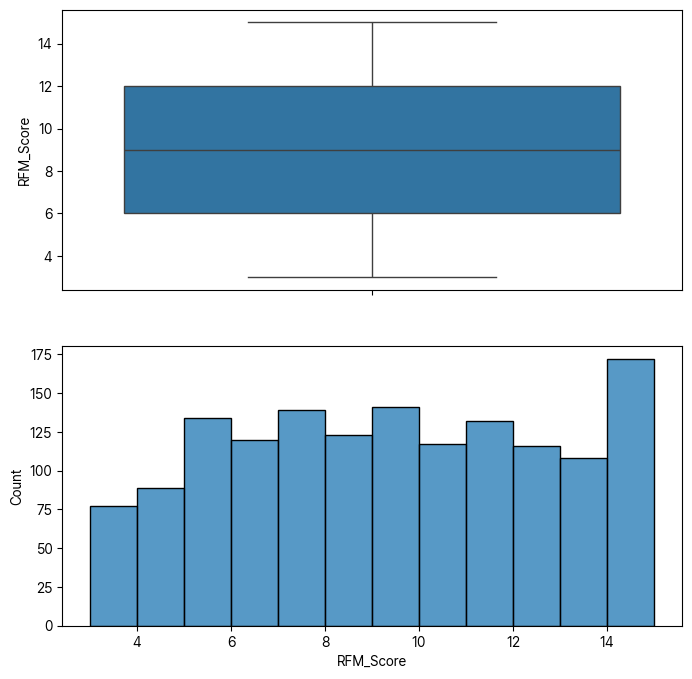

In [15]:
fig, ax = plt.subplots(2, 1, figsize=(8, 8))

sns.boxplot(RFM['RFM_Score'], ax=ax[0]);
sns.histplot(RFM['RFM_Score'], ax=ax[1]);

##### 고객 Segment 생성

In [16]:
bins = [2, 6, 9, 12, 15]
labels = ['이탈 위험 고객', '일반 고객', '우수 고객', 'VIP 고객']

RFM['Segment'] = pd.cut(
    RFM['RFM_Score'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [18]:
RFM['R_Score'] = RFM['R_Score'].astype(int)
RFM['F_Score'] = RFM['F_Score'].astype(int)
RFM['M_Score'] = RFM['M_Score'].astype(int)

##### Segment 결과 확인

In [19]:
RFM.groupby('Segment').agg(
    고객수 = ('고객ID', 'nunique'),
    R_mean = ('R', 'mean'),
    F_mean = ('F', 'mean'),
    M_mean = ('M', 'mean'),
    R_median = ('R', 'median'),
    F_median = ('F', 'median'),
    M_median = ('M', 'median'),
    R_Score_mean = ('R_Score', 'mean'),
    F_Score_mean = ('F_Score', 'mean'),
    M_Score_mean = ('M_Score', 'mean')
).round(2)

/var/folders/30/zs7bz7k92qb408lhy5d8dvdm0000gn/T/ipykernel_8471/3789751966.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  RFM.groupby('Segment').agg(


,고객수,R_mean,F_mean,M_mean,R_median,F_median,M_median,R_Score_mean,F_Score_mean,M_Score_mean
Segment,,,,,,,,,,
이탈 위험 고객,420,219.09,3.60,459.54,213.0,3.0,341.92,1.93,1.35,1.43
일반 고객,403,153.00,9.70,1532.24,141.0,9.0,1365.95,2.88,2.52,2.61
우수 고객,365,120.55,21.59,3712.30,102.0,18.0,3030.23,3.32,3.81,3.87
VIP 고객,280,50.53,47.60,8947.53,39.0,38.0,6765.68,4.41,4.72,4.78


In [17]:
df = df_merge.merge(RFM, on='고객ID', how='left')

In [22]:
# (우수, VIP) 고객은 평균 R,F,M이 중앙값 R,F,M보다 크다. -> 그룹 내 더 높은 수의 유저가 존재한다.

vip = RFM[RFM['Segment'] == 'VIP 고객']
vip['M_pct_rank'] = vip['M'].rank(pct=True)
top_vip = vip[vip['M_pct_rank']>=0.9]
top_vip_sales_share = (top_vip['M'].sum() / vip['M'].sum()) * 100
top_vip_sales_share

/var/folders/30/zs7bz7k92qb408lhy5d8dvdm0000gn/T/ipykernel_8471/4138279474.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vip['M_pct_rank'] = vip['M'].rank(pct=True)


np.float64(31.215431834895973)

#### **4.쿠폰 및 제품 카테고리 분석**

In [23]:
coupon_customer = pd.crosstab(df['고객ID'], df['쿠폰상태']).reset_index()

tmp = RFM[['고객ID', 'Segment']]
coupon_customer = coupon_customer.merge(tmp, how='left', on='고객ID')
coupon_customer.head()

,고객ID,Clicked,Not Used,Used,Segment
0,USER_0000,0,0,2,이탈 위험 고객
1,USER_0001,26,14,20,VIP 고객
2,USER_0002,11,1,11,일반 고객
3,USER_0003,8,3,6,우수 고객
4,USER_0004,17,8,11,일반 고객


In [24]:
coupon_customer['전체쿠폰건수'] = coupon_customer['Clicked'] + coupon_customer['Not Used'] + coupon_customer['Used']
coupon_customer['쿠폰클릭비율'] = coupon_customer['Clicked'] / coupon_customer['전체쿠폰건수']
coupon_customer['쿠폰사용비율'] = coupon_customer['Used'] / coupon_customer['전체쿠폰건수']
coupon_customer['쿠폰미사용비율'] = coupon_customer['Not Used'] / coupon_customer['전체쿠폰건수']

In [25]:
coupon_customer_graph = coupon_customer.groupby('Segment').agg(
    고객수 = ('고객ID', 'nunique'),
    평균_쿠폰클릭비율 = ('쿠폰클릭비율', 'mean'),
    평균_쿠폰미사용비율 = ('쿠폰사용비율', 'mean'),
    평균_쿠폰사용비율 = ('쿠폰미사용비율', 'mean'),
    중앙값_쿠폰클릭비율 = ('쿠폰클릭비율', 'median'),
    중앙값_쿠폰미사용비율 = ('쿠폰사용비율', 'median'),
    중앙값_쿠폰사용비율 = ('쿠폰미사용비율', 'median')
).round(2)
coupon_customer_graph = coupon_customer_graph.reset_index()

/var/folders/30/zs7bz7k92qb408lhy5d8dvdm0000gn/T/ipykernel_8471/2156662597.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  coupon_customer_graph = coupon_customer.groupby('Segment').agg(


In [26]:
coupon_productCategory = pd.crosstab(df['제품카테고리'], df['쿠폰상태']).reset_index()
coupon_productCategory['전체쿠폰건수'] = coupon_productCategory['Clicked'] + coupon_productCategory['Not Used'] + coupon_productCategory['Used']
coupon_productCategory.head(2)

쿠폰상태,제품카테고리,Clicked,Not Used,Used,전체쿠폰건수
0,Accessories,125,32,77,234
1,Android,23,10,10,43


In [27]:
coupon_productCategory['쿠폰클릭비율'] = coupon_productCategory['Clicked'] / coupon_productCategory['전체쿠폰건수'] * 100
coupon_productCategory['쿠폰미사용비율'] = coupon_productCategory['Not Used'] / coupon_productCategory['전체쿠폰건수'] * 100
coupon_productCategory['쿠폰사용비율'] = coupon_productCategory['Used'] / coupon_productCategory['전체쿠폰건수'] * 100

In [28]:
status_cols = ['Clicked', 'Not Used', 'Used']

customer_category_coupon = df.groupby(['고객ID', '제품카테고리', '쿠폰상태'], observed=True).size().unstack('쿠폰상태', fill_value=0)
customer_category_coupon.columns.name = None
customer_category_coupon = customer_category_coupon.reset_index()

customer_category_coupon['전체건수'] = customer_category_coupon[status_cols].sum(axis=1)
customer_category_coupon['쿠폰클릭비율'] = customer_category_coupon['Clicked'] / customer_category_coupon['전체건수'] * 100
customer_category_coupon['쿠폰미사용비율'] = customer_category_coupon['Not Used'] / customer_category_coupon['전체건수'] * 100
customer_category_coupon['쿠폰사용비율'] = customer_category_coupon['Used'] / customer_category_coupon['전체건수'] * 100

customer_category_coupon = customer_category_coupon.reset_index()
customer_category_coupon = customer_category_coupon.merge(tmp, how='left', on='고객ID')
customer_category_coupon

,index,고객ID,제품카테고리,Clicked,Not Used,Used,전체건수,쿠폰클릭비율,쿠폰미사용비율,쿠폰사용비율,Segment
0,0,USER_0000,Apparel,0,0,1,1,0.000000,0.000000,100.000000,이탈 위험 고객
1,1,USER_0000,Office,0,0,1,1,0.000000,0.000000,100.000000,이탈 위험 고객
2,2,USER_0001,Accessories,1,0,0,1,100.000000,0.000000,0.000000,VIP 고객
3,3,USER_0001,Apparel,8,7,4,19,42.105263,36.842105,21.052632,VIP 고객
4,4,USER_0001,Bags,0,2,0,2,0.000000,100.000000,0.000000,VIP 고객
...,...,...,...,...,...,...,...,...,...,...,...
8881,8881,USER_1467,Nest,1,0,2,3,33.333333,0.000000,66.666667,VIP 고객
8882,8882,USER_1467,Nest-USA,9,2,5,16,56.250000,12.500000,31.250000,VIP 고객
8883,8883,USER_1467,Notebooks & Journals,1,0,0,1,100.000000,0.000000,0.000000,VIP 고객
8884,8884,USER_1467,Office,6,3,4,13,46.153846,23.076923,30.769231,VIP 고객


In [30]:
summary_customer_category = (
    customer_category_coupon.groupby(
        ['Segment', '제품카테고리'],
        observed=True
    ).agg(
        구매고객수=('고객ID', 'nunique'),
        평균_쿠폰클릭비율=('쿠폰클릭비율', 'mean'),
        평균_쿠폰미사용비율=('쿠폰미사용비율', 'mean'),
        평균_쿠폰사용비율=('쿠폰사용비율', 'mean')
    ).round(2).reset_index()
)

##### Segment별 전체 고객 수

In [31]:
segment_customer_count = (
    RFM.groupby('Segment', observed=True)['고객ID'].nunique()
)

summary_customer_category['Segment_전체고객수'] = (
    summary_customer_category['Segment'].map(
        segment_customer_count
    ).astype(int)
)

##### 카테고리 구매 침투율

In [ ]:
summary_customer_category['카테고리_구매고객비율'] = (
    summary_customer_category['구매고객수'] /
    summary_customer_category['Segment_전체고객수'] * 100
)

summary_customer_category = (
    summary_customer_category
    .round(2)
)

summary_customer_category.head()

,Segment,제품카테고리,구매고객수,평균_쿠폰클릭비율,평균_쿠폰미사용비율,평균_쿠폰사용비율,Segment_전체고객수,카테고리_구매고객비율
0,이탈 위험 고객,Accessories,5,30.0,40.00,30.00,420,1.19
1,이탈 위험 고객,Android,2,50.0,0.00,50.00,420,0.48
2,이탈 위험 고객,Apparel,320,47.1,16.78,36.11,420,76.19
3,이탈 위험 고객,Backpacks,4,50.0,0.00,50.00,420,0.95
4,이탈 위험 고객,Bags,93,56.0,12.28,31.72,420,22.14


##### Segment별 상위 제품 카테고리

In [ ]:
top_category_by_segment = (
    summary_customer_category.sort_values(['Segment', '카테고리_구매고객비율'],
        ascending=[True, False]
    ).groupby('Segment',observed=True)
)

top_category_by_segment[
    [    
        'Segment',
        '제품카테고리',
        '구매고객수',
        'Segment_전체고객수',
        '카테고리_구매고객비율',
        '평균_쿠폰사용비율'
    ]
]

,Segment,제품카테고리,구매고객수,Segment_전체고객수,카테고리_구매고객비율,평균_쿠폰사용비율
2,이탈 위험 고객,Apparel,320,420,76.19,36.11
16,이탈 위험 고객,Nest-USA,239,420,56.90,30.06
18,이탈 위험 고객,Office,217,420,51.67,33.95
6,이탈 위험 고객,Drinkware,154,420,36.67,31.80
12,이탈 위험 고객,Lifestyle,130,420,30.95,37.99
4,이탈 위험 고객,Bags,93,420,22.14,31.72
10,이탈 위험 고객,Headgear,51,420,12.14,35.95
17,이탈 위험 고객,Notebooks & Journals,49,420,11.67,38.78
36,일반 고객,Nest-USA,377,403,93.55,33.08
22,일반 고객,Apparel,368,403,91.32,33.67


In [38]:
customer_category_count = (
    customer_category_coupon.groupby(
        ['Segment', '고객ID'],
        observed=True
    ).agg(
        구매카테고리수=('제품카테고리', 'nunique')
    ).reset_index()
)

##### 고객별 구매 카테고리 수

In [39]:
category_count_summary = (
    customer_category_count.groupby('Segment', observed=True).agg(
        고객수=('고객ID', 'nunique'),
        평균_구매카테고리수=('구매카테고리수', 'mean'),
        중앙값_구매카테고리수=('구매카테고리수', 'median'),
        최대_구매카테고리수=('구매카테고리수', 'max')
    ).round(2)
)

category_count_summary

,고객수,평균_구매카테고리수,중앙값_구매카테고리수,최대_구매카테고리수
Segment,,,,
이탈 위험 고객,420,3.26,3.0,9
일반 고객,403,5.29,5.0,13
우수 고객,365,7.49,7.0,15
VIP 고객,280,9.47,9.0,19
